# 08 - Blind Spot Analysis

Purpose:
- classify every traditional risk event (VaR breach, portfolio volatility spike, drawdown)
  by which alarm caught it: the Gold alarm (Steps 04/06), the Brent-only baseline (Step 07),
  both, or neither;
- following Step 07's "Fair Comparison: Early-Warning-Only Matching" finding, "caught" here
  means the alarm fired with `lead_days >= 1` (strictly before the event) - same-day
  confirmations do not count as a catch;
- identify "blind spot" events that neither signal anticipated with genuine lead time;
- cluster blind-spot event dates into episodes and inspect the underlying Gold, Brent, DXY,
  VIX, and US10Y moves to assess whether the misses are Brent-specific (e.g. supply-side oil
  shocks) or genuine cross-market misses.

Core framing:
A useful dashboard does not need to catch every event, but it is important to understand what
it systematically misses, and whether those misses share a recognisable pattern.

## Reader Orientation

This notebook does not build a new alarm. It cross-references the event-level results from
Step 06 (Gold alarm) and Step 07 (Brent-only baseline) to answer: for each VaR breach,
volatility spike, or drawdown event, did either signal give genuine advance warning
(`lead_days >= 1`)? Events that neither signal caught with lead time are grouped into
"blind spot" episodes and examined using the underlying Gold, Brent, DXY, VIX, and US10Y
moves around them.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
gold_lead_path = ROOT / "outputs" / "step06" / "lead_time_table.csv"
brent_lead_path = ROOT / "outputs" / "step07" / "brent_baseline_lead_time_table.csv"

market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

for path in [gold_lead_path, brent_lead_path, market_vars_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required input not found: {path}")

gold_lead = pd.read_csv(gold_lead_path, parse_dates=["event_date", "alarm_date"])
brent_lead = pd.read_csv(brent_lead_path, parse_dates=["event_date", "alarm_date"])
market_vars = pd.read_parquet(market_vars_path)

print("Gold lead-time rows:", len(gold_lead))
print("Brent baseline lead-time rows:", len(brent_lead))
gold_lead.head()

Gold lead-time rows: 234
Brent baseline lead-time rows: 234


,event_date,matched,alarm_date,lead_days,event_family
0,2011-03-15,False,NaT,NaN,var_breach
1,2011-05-05,True,2011-05-05,0.0,var_breach
2,2011-05-11,True,2011-05-05,6.0,var_breach
3,2011-06-15,False,NaT,NaN,var_breach
4,2011-06-23,True,2011-06-23,0.0,var_breach


## Classify Each Event By Which Alarm Caught It

Following Step 07's "Fair Comparison: Early-Warning-Only Matching" section, "caught" here
means the alarm fired **strictly before** the event (`matched & lead_days >= 1`), not merely
within the 30-day lookback. Same-day (`lead_days == 0`) hits no longer count, since they
confirm a shock as it happens rather than providing advance warning.

For each `(event_date, event_family)` pair, an event is classified as:
- **Both**: both signals gave >=1 day of advance warning,
- **Gold only**: only Gold gave >=1 day of advance warning,
- **Brent baseline only**: only the Brent baseline gave >=1 day of advance warning,
- **Blind spot**: neither signal gave any advance warning (includes same-day-only and
  no-match cases).

In [3]:
merged = gold_lead.merge(
    brent_lead,
    on=["event_date", "event_family"],
    how="outer",
    suffixes=("_gold", "_brent"),
)
merged["matched_gold"] = merged["matched_gold"].fillna(False) & (merged["lead_days_gold"] >= 1)
merged["matched_brent"] = merged["matched_brent"].fillna(False) & (merged["lead_days_brent"] >= 1)


def classify(row):
    if row["matched_gold"] and row["matched_brent"]:
        return "Both"
    if row["matched_gold"]:
        return "Gold only"
    if row["matched_brent"]:
        return "Brent baseline only"
    return "Blind spot"


merged["classification"] = merged.apply(classify, axis=1)
merged = merged.sort_values(["event_family", "event_date"]).reset_index(drop=True)

merged["classification"].value_counts()

classification
Blind spot             80
Gold only              68
Both                   47
Brent baseline only    39
Name: count, dtype: int64

### Result Comment And Significance

Following Step 07's fair-comparison redefinition (a "catch" requires `lead_days >= 1`, i.e.
the alarm fired strictly before the event), the four-way split across all 234 event-dates
changes substantially from the lookback-only version:

- **Blind spot** (neither gave advance warning): 80 events (34.2%) - up from 11.1%
- **Gold only**: 68 events (29.1%) - up from 8.1%
- **Both**: 47 events (20.1%) - down from 52.1%
- **Brent baseline only**: 39 events (16.7%) - down from 28.6%

Combined early-warning coverage (Both + Gold only + Brent baseline only) is 154/234 =
**65.8%**, down from 88.9% under the lookback-only definition. The composition also flips:
Gold now contributes more standalone early warning than the naive Brent baseline (29.1% vs
16.7% of all events), consistent with Step 07's finding that the Brent baseline's apparent
edge was mostly same-day confirmation rather than genuine foresight.

## Classification Summary By Event Family

In [4]:
classification_summary = (
    merged.groupby(["event_family", "classification"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Both", "Gold only", "Brent baseline only", "Blind spot"], fill_value=0)
)
classification_summary["total_events"] = classification_summary.sum(axis=1)
classification_pct = (
    classification_summary
    .div(classification_summary["total_events"], axis=0)
    .drop(columns="total_events")
    .round(3)
)

classification_summary

classification,Both,Gold only,Brent baseline only,Blind spot,total_events
event_family,,,,,
drawdown_event,0,4,0,11,15
portfolio_vol_spike,6,7,5,3,21
var_breach,41,57,34,66,198


### Result Comment And Significance

Under the early-warning-only definition, the per-family picture changes substantially too:

- **portfolio_vol_spike (21 events)**: no longer fully covered. 6 (28.6%) are caught by both
  signals with >=1 day lead, 7 (33.3%) by Gold only, 5 (23.8%) by the Brent baseline only,
  and **3 (14.3%) are now blind spots** - small new gaps that appear once the same-day Brent
  confirmations that previously covered 100% of this family are excluded.
- **var_breach (198 events)**: 41 (20.7%) caught by both, 57 (28.8%) by Gold only, 34 (17.2%)
  by the Brent baseline only, and **66 (33.3%) are blind spots**, up sharply from 8.6%. Most
  of this family's "Brent baseline only" and "Both" matches under the lookback-only
  definition were same-day, so they collapse into "Blind spot" once advance notice is
  required.
- **drawdown_event (15 events)**: Gold only now accounts for all of the non-blind-spot
  events (4, 26.7%); the Brent baseline contributes **zero** early-warning catches for
  drawdown events (both of its previous matches were same-day). **11 of 15 (73.3%) are
  blind spots**, up from 60.0% - drawdown events remain by far the worst-covered family, and
  the episode analysis below confirms this is structural.

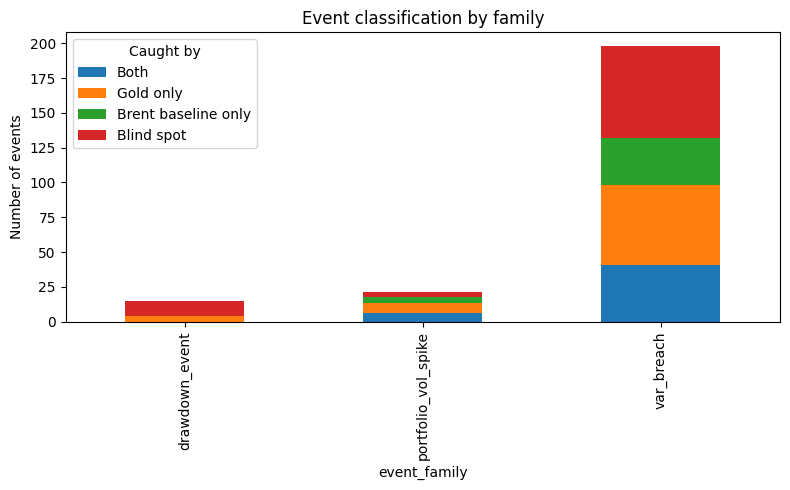

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
classification_summary[["Both", "Gold only", "Brent baseline only", "Blind spot"]].plot(
    kind="bar", stacked=True, ax=ax
)
ax.set_title("Event classification by family")
ax.set_ylabel("Number of events")
ax.legend(title="Caught by")
plt.tight_layout()

## Blind Spot Episodes

Many "Blind spot" events are not isolated: a single stress period (e.g. an oil supply shock)
can register as several separate event-starts a few days apart. Blind-spot event dates that
fall within `BLIND_SPOT_GAP_DAYS` of each other are grouped into a single episode, and the
average Gold, Brent, DXY, VIX, and US10Y moves over a window spanning
`CONTEXT_LOOKBACK_DAYS` before the episode through its end are computed for interpretation.

Under the early-warning-only definition there are many more blind-spot dates than before, so
each episode is also tagged with a `dominant_pattern`: `cumulative_drawdown` (any
`drawdown_event` in the episode), `broad_market_stress` (mean `d_VIX` over the window
>= `BROAD_MARKET_VIX_THRESHOLD`), or `single_day_brent_move` (everything else). The full
per-episode table is saved to `blind_spot_episodes.csv`; the commentary below summarises by
pattern rather than enumerating all episodes.

In [6]:
BLIND_SPOT_GAP_DAYS = 10
CONTEXT_LOOKBACK_DAYS = 5
BROAD_MARKET_VIX_THRESHOLD = 1.5

blind_spots = merged.loc[merged["classification"] == "Blind spot"].copy()
blind_spot_dates = pd.DatetimeIndex(sorted(blind_spots["event_date"].unique()))


def cluster_dates(dates, gap_days):
    groups = []
    current = [dates[0]]
    for d in dates[1:]:
        if (d - current[-1]).days <= gap_days:
            current.append(d)
        else:
            groups.append(current)
            current = [d]
    groups.append(current)
    return groups


episode_groups = cluster_dates(blind_spot_dates, BLIND_SPOT_GAP_DAYS)

episode_rows = []
for i, group in enumerate(episode_groups, start=1):
    start, end = group[0], group[-1]
    events_in_group = blind_spots.loc[blind_spots["event_date"].isin(group)]
    window = market_vars.loc[
        (market_vars.index >= start - pd.Timedelta(days=CONTEXT_LOOKBACK_DAYS))
        & (market_vars.index <= end)
    ]
    families = sorted(events_in_group["event_family"].unique())
    has_drawdown = "drawdown_event" in families
    mean_d_vix = window["d_VIX"].mean()
    if has_drawdown:
        pattern = "cumulative_drawdown"
    elif mean_d_vix >= BROAD_MARKET_VIX_THRESHOLD:
        pattern = "broad_market_stress"
    else:
        pattern = "single_day_brent_move"
    episode_rows.append({
        "episode": i,
        "start_date": start,
        "end_date": end,
        "n_event_dates": len(group),
        "n_blind_spot_events": len(events_in_group),
        "event_families": ", ".join(families),
        "dominant_pattern": pattern,
        "mean_r_Gold": window["r_Gold"].mean(),
        "mean_r_Brent": window["r_Brent"].mean(),
        "mean_r_DXY": window["r_DXY"].mean(),
        "mean_d_VIX": mean_d_vix,
        "mean_d_US10Y": window["d_US10Y"].mean(),
    })

blind_spot_episodes = pd.DataFrame(episode_rows)

print("Blind spot event-dates:", len(blind_spot_dates))
print("Blind spot episodes:", len(blind_spot_episodes))
print()
print(blind_spot_episodes["dominant_pattern"].value_counts())
print()

pattern_summary = (
    blind_spot_episodes
    .groupby("dominant_pattern")
    .agg(
        n_episodes=("episode", "count"),
        date_range_start=("start_date", "min"),
        date_range_end=("end_date", "max"),
        mean_abs_r_Brent=("mean_r_Brent", lambda x: x.abs().mean()),
        mean_abs_r_Gold=("mean_r_Gold", lambda x: x.abs().mean()),
        mean_d_VIX=("mean_d_VIX", "mean"),
    )
)
pattern_summary

Blind spot event-dates: 75
Blind spot episodes: 65

dominant_pattern
single_day_brent_move    51
cumulative_drawdown      10
broad_market_stress       4
Name: count, dtype: int64



,n_episodes,date_range_start,date_range_end,mean_abs_r_Brent,mean_abs_r_Gold,mean_d_VIX
dominant_pattern,,,,,,
broad_market_stress,4,2015-08-24,2025-04-03,0.023998,0.005167,3.880000
cumulative_drawdown,10,2010-01-14,2012-04-03,0.009848,0.004242,0.584298
single_day_brent_move,51,2011-06-23,2025-12-26,0.011710,0.004452,0.201870


### Result Comment And Significance

The 75 blind-spot event-dates cluster into **65 episodes**, which split into three
structural patterns:

**1. `cumulative_drawdown` (10 episodes, 11 event-dates, all between 2010-01-14 and
2012-04-03).** This is the same European-sovereign-debt-crisis cluster identified under the
lookback-only definition, now slightly larger (10 episodes vs 8). Average moves over these
windows are modest (|r_Brent| ~0.98%, |r_Gold| ~0.42%, d_VIX ~0.58) - a -5% NAV drawdown is a
cumulative, path-dependent measure that single-day `|z|>2.0` return/vol rules are
structurally not designed to detect, regardless of the lead-time threshold.

**2. `single_day_brent_move` (51 episodes, 2011-06-23 to 2025-12-26) - the dominant pattern,
accounting for 78% of all episodes.** Average |r_Brent| (~1.17%) is roughly 2.6x average
|r_Gold| (~0.45%), and d_VIX is essentially flat (~0.20). These are days where Brent itself
made an outsized move large enough to breach the book's VaR - the move *is* the event, so by
definition nothing can give 1+ day advance warning of it. This is the sharpest empirical
evidence yet for the "Gold does not predict Brent's day-to-day returns" limitation: a large
share of the residual blind-spot rate is not a dashboard design gap, but a restatement of
that limitation in VaR-breach terms.

**3. `broad_market_stress` (4 episodes: 2015-08-24, 2018-12-24, 2020-06-11, 2025-04-03).**
These are the genuinely concerning near-misses - real risk-off days with d_VIX averaging
+3.88 (vs ~0.2-0.6 for the other two patterns) and |r_Brent| ~2.4%, yet still without 1+ day
advance warning from either signal:
- **2015-08-24** (China-devaluation / oil-crash): d_VIX +6.74, r_Brent -3.35%, r_Gold +0.80%.
- **2020-06-11** (post-COVID vol-regime): d_VIX +4.07, r_Brent -2.32%, r_Gold +0.82%.
- **2018-12-24** (Dec-2018 selloff): d_VIX +2.62, r_Brent -2.72%, r_Gold +0.36%.
- **2025-04-03**: d_VIX +2.09, r_Brent -1.21%, r_Gold +0.08%.

In each, Gold moved in the *opposite* direction to Brent (a flight-to-quality pattern), which
is consistent with Gold's relationship signals not flagging anything unusual - the cross-asset
correlations were behaving "normally" even as Brent sold off sharply.

## Step 08 Working Takeaways

- **Adopting Step 07's early-warning-only definition (`lead_days >= 1`) roughly triples the
  blind-spot rate from 11.1% to 34.2%** (26 -> 80 of 234 events), and combined early-warning
  coverage falls from 88.9% to 65.8%. This is the "fair" number: it strips out same-day
  confirmations that don't give the risk desk any time to act.
- **The composition flips in Gold's favour**: Gold-only catches rise from 8.1% to 29.1% of
  all events, while Brent-baseline-only catches fall from 28.6% to 16.7%. Under a genuine
  early-warning standard, Gold's cross-market signal is now the larger standalone
  contributor, not the naive Brent rule.
- **`drawdown_event` remains the worst-covered family (73.3% blind-spot rate, up from
  60.0%), and this is structural, not a threshold artifact**: all 11 blind-spot dates fall in
  the 2010-2012 European-debt-crisis era, reflecting cumulative NAV erosion that single-day
  `|z|>2.0` rules - at any lead-time threshold - are not designed to catch.
- **The dominant new pattern (51 of 65 episodes, 78%) is `single_day_brent_move`**: days
  where an outsized Brent move itself breaches the book's VaR, with no accompanying
  cross-market dislocation (|r_Brent| ~1.17% vs |r_Gold| ~0.45%, d_VIX ~0.2). These cannot be
  given 1+ day advance warning by construction - the move *is* the information. This is
  direct empirical evidence for the "Gold does not predict Brent's returns" limitation
  reserved for the presentation discussion.
- **4 episodes (`broad_market_stress`: 2015-08-24, 2018-12-24, 2020-06-11, 2025-04-03) are
  the genuinely concerning near-misses** - real risk-off days (d_VIX +2.1 to +6.7) where Gold
  moved opposite to Brent (flight-to-quality) and so gave no warning via its relationship
  signals.
- Net read: under the fair, early-warning-only standard, roughly 1 in 3 traditional risk
  events gets no advance notice from either signal - but ~80% of that gap (cumulative
  drawdowns + single-day Brent shocks) is structurally out of scope for any `|z|>2.0`
  same-day signal, and the residual ~20% (broad-market near-misses) is where future signal
  design effort would have the highest payoff.

In [7]:
merged.to_csv(OUTPUT_DIR / "event_classification_table.csv", index=False)
classification_summary.to_csv(OUTPUT_DIR / "blind_spot_summary.csv")
classification_pct.to_csv(OUTPUT_DIR / "blind_spot_summary_pct.csv")
blind_spot_episodes.to_csv(OUTPUT_DIR / "blind_spot_episodes.csv", index=False)
pattern_summary.to_csv(OUTPUT_DIR / "blind_spot_episode_patterns.csv")

print("Saved Step 08 blind-spot outputs to:", OUTPUT_DIR)

Saved Step 08 blind-spot outputs to: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\outputs\step08
